# Public Library Survey × ACS Socioeconomic Analysis
**Data sources:**
- *Public Library Survey (PLS) FY2023* — IMLS agency-level and outlet-level microdata
- *American Community Survey (ACS) 5-Year Estimates 2023, DP03* — county-level economic characteristics

**Project timeline covered in this notebook:**
| Phase | Dates | Section |
|---|---|---|
| Data Cleaning & Preprocessing | Mar 24 – 27 | §1 |
| Exploratory Data Analysis | Mar 27 – 30 | §2 |
| Feature Engineering | Apr 1 – 6 | §3 |
| Data Quality & Documentation | Apr 7 – 12 | §4 |


## §0 — Imports & File Paths

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


# ── Display settings ──────────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# ── File paths ────────────────────────────────────────────────
# Update these paths if you move the data files.
"PATH_ACS_META  = \"ACSDP5Y2023_DP03-Column-Metadata.csv\"\n",
"PATH_ACS_DATA  = \"ACSDP5Y2023_DP03-Data.csv\"\n",
"PATH_PLS_AE    = \"PLS_FY23_AE_pud23i.csv\"      # Agency-level (one row per library system)\n",
"PATH_PLS_OUT   = \"pls_fy23_outlet_pud23i.csv\"   # Outlet-level (branches / bookmobiles)\n",

print("Imports OK")



Imports OK


---
## §1 — Data Cleaning & Preprocessing
*Mar 24 – 27*

### 1.1 Load raw files


In [391]:
# ── ACS metadata (column code → human label) ─────────────────
acs_meta = pd.read_csv(PATH_ACS_META)
print(f"ACS metadata: {acs_meta.shape[0]} column definitions")
acs_meta.head()


ACS metadata: 550 column definitions


,Column Name,Label
0,GEO_ID,Geography
1,NAME,Geographic Area Name
2,DP03_0001E,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...
3,DP03_0001M,Margin of Error!!EMPLOYMENT STATUS!!Population...
4,DP03_0002E,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...


In [392]:
# ── ACS data ─────────────────────────────────────────────────
# Row 0 is a second header row (human-readable labels); skip it with skiprows=[1].
acs_raw = pd.read_csv(PATH_ACS_DATA, skiprows=[1], low_memory=False)
print(f"ACS: {acs_raw.shape[0]:,} counties × {acs_raw.shape[1]} columns")
acs_raw.head(2)


ACS: 3,222 counties × 551 columns


,GEO_ID,NAME,DP03_0001E,DP03_0001M,DP03_0002E,DP03_0002M,DP03_0003E,DP03_0003M,DP03_0004E,DP03_0004M,DP03_0005E,DP03_0005M,DP03_0006E,DP03_0006M,DP03_0007E,...,DP03_0131PE,DP03_0131PM,DP03_0132PE,DP03_0132PM,DP03_0133PE,DP03_0133PM,DP03_0134PE,DP03_0134PM,DP03_0135PE,DP03_0135PM,DP03_0136PE,DP03_0136PM,DP03_0137PE,DP03_0137PM,Unnamed: 550
0,0500000US01001,"Autauga County, Alabama",47508,227,28020,890,27070,978,26382,966,688,234,950,273,19488,...,15.9,7.9,11.7,3.9,10.00,1.70,11.00,2.10,6.20,1.50,8.40,1.90,22.90,3.60,NaN
1,0500000US01003,"Baldwin County, Alabama",195048,457,113778,1904,113171,1913,109556,1998,3615,584,607,266,81270,...,16.5,3.5,13.3,2.2,9.50,0.90,10.30,1.10,7.20,1.10,8.10,1.00,22.80,2.10,NaN


In [393]:
# ── PLS agency-level ──────────────────────────────────────────
pls_raw = pd.read_csv(PATH_PLS_AE, low_memory=False, encoding='latin1')
print(f"PLS agencies: {pls_raw.shape[0]:,} rows × {pls_raw.shape[1]} columns")
pls_raw.head(2) 


PLS agencies: 9,252 rows × 187 columns


,STABR,FSCSKEY,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,ADDRES_M,CITY_M,ZIP_M,ZIP4_M,CNTY,PHONE,C_RELATN,...,LATITUDE,LSAGEOID,LSAGEORATIO,LSAGEOTYPE,CNTYPOP,LOCALE_ADD,LOCALE_MOD,CENTRACT,CENBLOCK,CDCODE,CBSA,MICROF,GEOSTATUS,GEOSCORE,GEOMTYPE
0,AK,AK0001,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,9150,P.O. BOX 129,ANCHOR POINT,99556,M,KENAI PENINSULA,9072355692,NO,...,59.78,203110,1.05,PLACE,61223,43,43,02122000800,021220008003027,200,-4,N,E,100.00,POINTADDRESS
1,AK,AK0002,AK0002-011,ANCHORAGE PUBLIC LIBRARY,3600 DENALI STREET,ANCHORAGE,99503,6093,3600 DENALI STREET,ANCHORAGE,99503,6093,ANCHORAGE,9073432892,NO,...,61.19,02020,0.99,COUNTY,286075,11,11,02020001900,020200019004016,200,11260,0,E,100.00,POINTADDRESS


In [394]:
# ── PLS outlet-level ──────────────────────────────────────────
outlet_raw = pd.read_csv(PATH_PLS_OUT, low_memory=False, encoding='latin1')
print(f"PLS outlets: {outlet_raw.shape[0]:,} rows × {outlet_raw.shape[1]} columns")
outlet_raw.head(2)


PLS outlets: 17,586 rows × 37 columns


,STABR,FSCSKEY,FSCS_SEQ,C_FSCS,LIBID,LIBNAME,ADDRESS,CITY,ZIP,ZIP4,CNTY,PHONE,C_OUT_TY,SQ_FEET,F_SQ_FT,...,STATSTRU,STATNAME,STATADDR,LONGITUD,LATITUDE,CNTYPOP,LOCALE,CENTRACT,CENBLOCK,CDCODE,CBSA,MICROF,GEOSTATUS,GEOSCORE,GEOMTYPE
0,AK,AK0001,2,Y,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,34020 NORTH FORK ROAD,ANCHOR POINT,99556,M,KENAI PENINSULA,9072355692,CE,2880,R_23,...,0,0,0,-151.83,59.78,61223,43,2122000800,021220008003027,200,-4,N,E,100.00,POINTADDRESS
1,AK,AK0002,7,Y,AK0002-007,CHUGIAK-EAGLE RIVER LIBRARY,12001 BUSINESS BOULEVARD #176,EAGLE RIVER,99577,7743,ANCHORAGE,9073431530,BR,2653,R_23,...,0,0,0,-149.57,61.33,286075,31,2020000201,020200002012000,200,11260,0,E,100.00,SUBADDRESS


### 1.2 Select relevant ACS columns (socioeconomic predictors)

In [395]:
# ── Build a lookup dict from the metadata ────────────────────
meta_lookup = dict(zip(acs_meta["Column Name"], acs_meta["Label"]))

# ── Priority socioeconomic predictor columns ──────────────────
# We keep Estimate (E) columns for key indicators and their Percent (PE) variants.
# Margin-of-error (M/PM) columns are dropped for now; add them back if doing
# uncertainty-aware modeling.

ACS_KEEP = {
    # Employment
    "DP03_0005PE": "unemployment_rate_pct",
    # Income
    "DP03_0062E":  "median_hh_income",
    "DP03_0063E":  "mean_hh_income",
    "DP03_0086E":  "per_capita_income",
    # Poverty
    "DP03_0099PE": "poverty_rate_all_pct",
    "DP03_0100PE": "poverty_rate_under18_pct",
    "DP03_0101PE": "poverty_rate_18to64_pct",
    # SNAP / food assistance
    "DP03_0074PE": "snap_pct",
    # Health insurance
    "DP03_0096PE": "no_health_insurance_pct",
    # Work-from-home
    "DP03_0042PE": "work_from_home_pct",
}

# Always keep geography columns
GEO_COLS = ["GEO_ID", "NAME"]

acs_sel = acs_raw[GEO_COLS + list(ACS_KEEP.keys())].copy()
acs_sel = acs_sel.rename(columns=ACS_KEEP)
print(f"ACS subset: {acs_sel.shape}")
acs_sel.head(3)


ACS subset: (3222, 12)


,GEO_ID,NAME,unemployment_rate_pct,median_hh_income,mean_hh_income,per_capita_income,poverty_rate_all_pct,poverty_rate_under18_pct,poverty_rate_18to64_pct,snap_pct,no_health_insurance_pct,work_from_home_pct
0,0500000US01001,"Autauga County, Alabama",1.40,69841,93367,83452,7.40,14632,2.7,8.80,92.60,19.00
1,0500000US01003,"Baldwin County, Alabama",1.90,75019,100105,92918,8.20,53342,4.9,6.80,91.80,19.30
2,0500000US01005,"Barbour County, Alabama",2.60,44290,64745,60474,10.80,5408,4.7,22.20,89.20,21.40


In [396]:
# ── Decode ACS GEO_ID to 5-digit county FIPS ─────────────────
# GEO_ID format: "0500000US{STATE_FIPS}{COUNTY_FIPS}"  e.g. "0500000US01001"
acs_sel["county_fips"] = acs_sel["GEO_ID"].str.extract(r"US(\d{5})$")

# Drop the full GEO_ID (redundant once we have county_fips)
acs_sel = acs_sel.drop(columns=["GEO_ID"])
print(f"Parsed FIPS codes: {acs_sel['county_fips'].notna().sum():,} non-null")
acs_sel[["NAME", "county_fips"]].head(5)


Parsed FIPS codes: 3,222 non-null


,NAME,county_fips
0,"Autauga County, Alabama",01001
1,"Baldwin County, Alabama",01003
2,"Barbour County, Alabama",01005
3,"Bibb County, Alabama",01007
4,"Blount County, Alabama",01009


### 1.3 Select relevant PLS columns (library usage metrics)

The PLS agency file has 187 columns. We keep identity/geography fields, core usage
metrics, and financial variables. Flag-columns (e.g. `F_VISITS`) encode data quality
codes — we'll use them to identify suppressed or imputed values.


In [397]:
# ── Key PLS agency columns ───────────────────────────────────
PLS_KEEP = {
    # Identity
    "STABR":     "state",
    "FSCSKEY":   "fscskey",
    "LIBID":     "libid",
    "LIBNAME":   "lib_name",
    "CNTY":      "county_name",
    # Geography / linkage
    "LSAGEOID":  "lsa_geoid",
    "LSAGEOTYPE":"lsa_geotype",
    "LONGITUD":  "longitude",
    "LATITUDE":  "latitude",
    # Population served
    "POPU_LSA":  "pop_lsa",
    # Staffing
    "LIBRARIA":  "librarians_fte",
    "OTHPAID":   "other_paid_fte",
    "TOTSTAFF":  "total_staff_fte",
    # Financials
    "LOCGVT":    "local_govt_revenue",
    "STGVT":     "state_govt_revenue",
    "FEDGVT":    "federal_revenue",
    "TOTINCM":   "total_income",
    "SALARIES":  "salaries_exp",
    "TOTOPEXP":  "total_opex",
    # Collections
    "BKVOL":     "print_volumes",
    "EBOOK":     "ebook_titles",
    # Usage — visits & circulation
    "VISITS":    "visits",
    "TOTCIR":    "total_circ",
    "KIDCIRCL":  "kids_circ",
    "ELMATCIR":  "elec_mat_circ",
    "REGBOR":    "registered_borrowers",
    # Digital / reference
    "ELINFO":    "elec_info_retrievals",
    "ELCONT":    "elec_content_uses",
    "GPTERMS":   "public_internet_terminals",
    "PITUSR":    "internet_uses",
    "WIFISESS":  "wifi_sessions",
    # Programs & attendance
    "TOTPRO":    "total_programs",
    "TOTATTEN":  "total_attendance",
    "ONPRO":     "online_programs",
    "OFFPRO":    "inperson_programs",
    # Hours
    "HRS_OPEN":  "hrs_open",
    # Outlets
    "CENTLIB":   "central_libs",
    "BRANLIB":   "branch_libs",
    "BKMOB":     "bookmobiles",
    # Quality flags (keep for filtering)
    "F_VISITS":  "f_visits",
    "F_TOTCIR":  "f_totcir",
    "F_REGBOR":  "f_regbor",
    "F_TOTSTF":  "f_totstf",
}

pls = pls_raw[list(PLS_KEEP.keys())].copy().rename(columns=PLS_KEEP)
print(f"PLS subset: {pls.shape}")
pls.head(2)


PLS subset: (9252, 43)


,state,fscskey,libid,lib_name,county_name,lsa_geoid,lsa_geotype,longitude,latitude,pop_lsa,librarians_fte,other_paid_fte,total_staff_fte,local_govt_revenue,state_govt_revenue,...,public_internet_terminals,internet_uses,wifi_sessions,total_programs,total_attendance,online_programs,inperson_programs,hrs_open,central_libs,branch_libs,bookmobiles,f_visits,f_totcir,f_regbor,f_totstf
0,AK,AK0001,AK0001-002,ANCHOR POINT PUBLIC LIBRARY,KENAI PENINSULA,203110,PLACE,-151.83,59.78,2202,1.00,0.36,1.36,0,12016,...,5,693,4320,95,1235,92,3,1404,1,0,0,R_23,R_23,R_23,R_23
1,AK,AK0002,AK0002-011,ANCHORAGE PUBLIC LIBRARY,ANCHORAGE,02020,COUNTY,-149.88,61.19,289810,23.90,50.35,74.25,14587561,35000,...,138,47028,71113,1335,23353,1177,72,9736,1,4,0,R_23,R_23,R_23,R_23


### 1.4 Handle PLS sentinel values and missing data

In [398]:
# ── PLS encodes several special values ───────────────────────
# -1  = not applicable
# -3  = confidential / suppressed
# -9  = missing / not reported
# These appear in numeric columns and should become NaN.

PLS_SENTINELS = [-1, -3, -9]

NUMERIC_COLS = [
    "pop_lsa", "librarians_fte", "other_paid_fte", "total_staff_fte",
    "local_govt_revenue", "state_govt_revenue", "federal_revenue",
    "total_income", "salaries_exp", "total_opex",
    "print_volumes", "ebook_titles",
    "visits", "total_circ", "kids_circ", "elec_mat_circ",
    "registered_borrowers", "elec_info_retrievals", "elec_content_uses",
    "public_internet_terminals", "internet_uses", "wifi_sessions",
    "total_programs", "total_attendance", "online_programs", "inperson_programs",
    "hrs_open", "central_libs", "branch_libs", "bookmobiles",
]

before = pls[NUMERIC_COLS].isin(PLS_SENTINELS).sum().sum()
pls[NUMERIC_COLS] = pls[NUMERIC_COLS].replace(PLS_SENTINELS, np.nan)
after = pls[NUMERIC_COLS].isna().sum().sum()
print(f"Sentinel values replaced → {before:,} cells now NaN")


Sentinel values replaced → 8,472 cells now NaN


In [399]:
# ── ACS: replace ACS sentinel values ─────────────────────────
# ACS uses "(X)" for not applicable, "-" for zero-base percent, etc.
ACS_NUMERIC = list(ACS_KEEP.values())

for col in ACS_NUMERIC:
    acs_sel[col] = pd.to_numeric(acs_sel[col], errors="coerce")

# Quick missingness report
missing_acs = acs_sel[ACS_NUMERIC].isna().mean().mul(100).round(2)
print("ACS missing % per column:")
print(missing_acs.to_string())


ACS missing % per column:
unemployment_rate_pct      0.00
median_hh_income           0.06
mean_hh_income             0.00
per_capita_income          0.12
poverty_rate_all_pct       0.00
poverty_rate_under18_pct   0.00
poverty_rate_18to64_pct    0.06
snap_pct                   0.00
no_health_insurance_pct    0.00
work_from_home_pct         0.00


In [400]:
# ── PLS missingness overview ─────────────────────────────────
missing_pls = pls[NUMERIC_COLS].isna().mean().mul(100).round(1).sort_values(ascending=False)
print("PLS missing % per column (top 20):")
print(missing_pls.head(20).to_string())


PLS missing % per column (top 20):
salaries_exp           33.90
wifi_sessions          20.30
inperson_programs       6.20
online_programs         6.20
total_attendance        4.30
total_programs          4.10
hrs_open                2.00
internet_uses           0.80
elec_content_uses       0.80
elec_mat_circ           0.80
total_circ              0.80
print_volumes           0.70
ebook_titles            0.70
visits                  0.70
total_opex              0.70
kids_circ               0.70
librarians_fte          0.70
registered_borrowers    0.70
elec_info_retrievals    0.70
total_income            0.70


### 1.5 Build the county-level FIPS key for PLS and merge

In [401]:
# ── Derive county FIPS from PLS ──────────────────────────────
# Strategy:
#   • When LSAGEOTYPE == "COUNTY"  → pad lsa_geoid to 5 digits = county FIPS directly.
#   • When LSAGEOTYPE == "PLACE"   → the library serves a municipality; we can't map
#     directly to one county without a crosswalk. We fall back to CENTRACT, where the
#     first 5 digits of the 11-digit census tract ID are the county FIPS.
#
# NOTE: Some libraries span multiple counties (LSABOUND == "Y"). This merge assigns
# them to a single county — document this limitation in §4.

def derive_county_fips(row):
    if row["lsa_geotype"] == "COUNTY":
        # geoid stored as integer; zero-pad to 5 digits
        try:
            return str(int(row["lsa_geoid"])).zfill(5)
        except (ValueError, TypeError):
            return np.nan
    return np.nan  # handled next step

pls["county_fips_direct"] = pls.apply(derive_county_fips, axis=1)

print("Direct county FIPS (COUNTY type):",
      pls["county_fips_direct"].notna().sum(), "/", len(pls))
print("Remaining (PLACE/other):", pls["county_fips_direct"].isna().sum())


Direct county FIPS (COUNTY type): 1548 / 9252
Remaining (PLACE/other): 7704


In [402]:
# ── For PLACE-type libraries: extract county from LSAGEOID ───
# Census place GEOIDs are 7 digits: state(2) + place(5).
# We use LSAGEOID to look up county via CENTRACT if available in the agency file.
#
# Simpler fallback approach used here: re-read the raw data to get CENTRACT,
# then take the first 5 digits.

pls_raw_geo = pls_raw[["FSCSKEY", "CENTRACT", "LSAGEOTYPE"]].copy()
pls_raw_geo["CENTRACT"] = pls_raw_geo["CENTRACT"].astype(str).str.zfill(11)
pls_raw_geo["county_fips_tract"] = pls_raw_geo["CENTRACT"].str[:5]
# Only use this for non-county types (validity check: should be 5 digit numeric)
pls_raw_geo.loc[~pls_raw_geo["county_fips_tract"].str.match(r"^\d{5}$"), "county_fips_tract"] = np.nan

# Merge back
pls = pls.merge(
    pls_raw_geo[["FSCSKEY", "county_fips_tract"]], 
    left_on="fscskey",   # Look for this in the 'pls' dataframe
    right_on="FSCSKEY",  # Look for this in the 'pls_raw_geo' dataframe
    how="left"
)
# Combine: prefer direct COUNTY match, fall back to tract-derived
pls["county_fips"] = pls["county_fips_direct"].fillna(pls["county_fips_tract"])

n_matched = pls["county_fips"].notna().sum()
print(f"Library agencies with county FIPS: {n_matched:,} / {len(pls):,} ({n_matched/len(pls)*100:.1f}%)")


Library agencies with county FIPS: 9,252 / 9,252 (100.0%)


In [403]:
# ── Merge PLS × ACS on county FIPS ───────────────────────────
merged = pls.merge(acs_sel, on="county_fips", how="left", suffixes=("_pls", "_acs"))

print(f"Merged dataset: {merged.shape}")
print(f"Libraries with ACS match: {merged['median_hh_income'].notna().sum():,} / {len(merged):,}")


Merged dataset: (9252, 58)
Libraries with ACS match: 9,246 / 9,252


In [404]:
# ── Inspect merge quality ─────────────────────────────────────
# Libraries without a county ACS match (investigate)
unmatched = merged[merged["median_hh_income"].isna()][["lib_name", "state", "county_name", "lsa_geotype"]]
print("Unmatched sample:")
print(unmatched.head(10).to_string(index=False))
print("\nGeotype breakdown of unmatched:")
print(merged[merged["median_hh_income"].isna()]["lsa_geotype"].value_counts())


Unmatched sample:
                                                  lib_name state county_name        lsa_geotype
                             FELETI BARSTOW PUBLIC LIBRARY    AS  MA`OPUTASI       MULTI-COUNTY
                                GUAM PUBLIC LIBRARY SYSTEM    GU        GUAM              PLACE
                                  LEICESTER PUBLIC LIBRARY    MA   WORCESTER COUNTY SUBDIVISION
                                JOETEN-KIYU PUBLIC LIBRARY    MP      SAIPAN             COUNTY
                                ESMERALDA COUNTY LIBRARIES    NV   ESMERALDA             COUNTY
VIRGIN ISLANDS DIVISION OF LIBRARIES, ARCHIVES AND MUSEUMS    VI  ST. THOMAS              OTHER

Geotype breakdown of unmatched:
lsa_geotype
COUNTY                2
MULTI-COUNTY          1
PLACE                 1
COUNTY SUBDIVISION    1
OTHER                 1
Name: count, dtype: int64


In [405]:
# ── Save cleaned files ────────────────────────────────────────
pls.to_csv("pls_cleaned.csv", index=False)
acs_sel.to_csv("acs_cleaned.csv", index=False)
merged.to_csv("merged_pls_acs.csv", index=False)
print("Saved: pls_cleaned.csv, acs_cleaned.csv, merged_pls_acs.csv")


Saved: pls_cleaned.csv, acs_cleaned.csv, merged_pls_acs.csv


---
## §2 — Exploratory Data Analysis
*Mar 27 – 30*

### 2.1 Summary statistics


In [406]:
# Work on the merged dataset, restricting to rows that have valid population
df = merged[merged["pop_lsa"].notna() & (merged["pop_lsa"] > 0)].copy()
print(f"Working dataset: {len(df):,} libraries")


Working dataset: 9,210 libraries


In [407]:
# ── Summary stats for library usage metrics ──────────────────
USAGE_COLS = ["visits", "total_circ", "registered_borrowers",
              "total_programs", "total_attendance",
              "hrs_open", "public_internet_terminals", "wifi_sessions",
              "total_staff_fte", "total_opex", "pop_lsa"]

df[USAGE_COLS].describe().T.round(1)


,count,mean,std,min,25%,50%,75%,max
visits,"9,169.00","87,590.80","305,978.80",0.00,"5,631.00","20,251.00","67,508.00","11,597,585.00"
total_circ,"9,170.00","214,073.50","911,972.60",0.00,"8,990.20","31,933.00","116,382.50","21,873,148.00"
registered_borrowers,"9,170.00","16,980.80","79,958.20",0.00,984.20,"3,084.00","9,952.00","3,029,366.00"
total_programs,"8,860.00",514.80,"1,632.30",0.00,76.00,210.00,485.00,"92,825.00"
total_attendance,"8,836.00","10,582.80","31,984.60",0.00,961.00,"3,239.50","9,231.20","1,290,578.00"
hrs_open,"9,040.00","3,964.70","8,570.00",0.00,"1,664.00","2,296.00","3,042.00","216,654.00"
public_internet_terminals,"9,170.00",29.20,112.30,0.00,5.00,9.00,20.00,"4,341.00"
wifi_sessions,"7,371.00","55,617.80","562,856.30",0.00,"1,073.00","4,799.00","18,153.00","41,235,681.00"
total_staff_fte,"9,170.00",15.60,55.60,0.00,1.50,4.00,11.30,"2,100.70"
total_opex,"9,170.00","1,657,946.70","7,903,131.80",0.00,"90,013.00","281,547.50","982,938.20","371,494,656.00"


In [408]:
# ── Summary stats for ACS socioeconomic predictors ───────────
SOC_COLS = list(ACS_KEEP.values())

acs_sel[SOC_COLS].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
unemployment_rate_pct,"3,222.00",2.74,1.36,0.00,2.00,2.60,3.30,14.80
median_hh_income,"3,220.00","65,046.65","18,388.68","16,170.00","54,113.25","63,161.50","73,216.25","178,707.00"
mean_hh_income,"3,222.00","85,574.14","23,260.70","22,105.00","72,400.50","82,559.00","94,845.50","226,660.00"
per_capita_income,"3,218.00","81,505.05","21,604.36","17,160.00","69,009.25","79,708.00","92,264.75","211,445.00"
poverty_rate_all_pct,"3,222.00",9.15,4.97,0.00,5.60,8.00,11.50,44.30
poverty_rate_under18_pct,"3,222.00","24,404.92","77,292.06",0.00,"2,529.75","5,954.00","15,823.75","2,181,124.00"
poverty_rate_18to64_pct,"3,220.00",6.19,5.28,0.00,2.80,4.70,7.90,59.60
snap_pct,"3,222.00",13.48,8.97,0.00,7.90,11.80,16.40,71.30
no_health_insurance_pct,"3,222.00",90.85,4.97,55.70,88.50,92.00,94.40,100.00
work_from_home_pct,"3,222.00",23.25,4.65,0.00,20.40,22.90,25.80,48.00


### 2.2 Distribution checks — skewness & outliers

In [409]:
# ── Skewness table for usage metrics ─────────────────────────
skew_df = df[USAGE_COLS].apply(lambda c: pd.Series({
    "mean":     c.mean(),
    "median":   c.median(),
    "skewness": c.skew(),
    "kurtosis": c.kurt(),
    "pct_zero": (c == 0).mean() * 100,
    "n_valid":  c.notna().sum(),
})).T.round(3)

print("Skewness summary (|skew| > 1 = substantially skewed):")
skew_df.sort_values("skewness", ascending=False)


Skewness summary (|skew| > 1 = substantially skewed):


,mean,median,skewness,kurtosis,pct_zero,n_valid
wifi_sessions,"55,617.77","4,799.00",55.65,"3,922.28",3.24,"7,371.00"
total_programs,514.83,210.00,26.50,"1,248.58",1.58,"8,860.00"
total_opex,"1,657,946.74","281,547.50",20.55,688.96,0.01,"9,170.00"
registered_borrowers,"16,980.85","3,084.00",18.66,495.38,0.11,"9,170.00"
public_internet_terminals,29.23,9.00,17.80,488.29,0.49,"9,170.00"
total_attendance,"10,582.81","3,239.50",14.45,379.84,1.61,"8,836.00"
pop_lsa,"36,500.80","7,444.50",14.25,293.86,0.00,"9,210.00"
total_staff_fte,15.64,4.00,13.90,324.04,0.87,"9,170.00"
visits,"87,590.77","20,251.00",13.59,313.98,0.14,"9,169.00"
total_circ,"214,073.46","31,933.00",11.58,177.10,0.08,"9,170.00"


<Figure size 1800x1200 with 0 Axes>

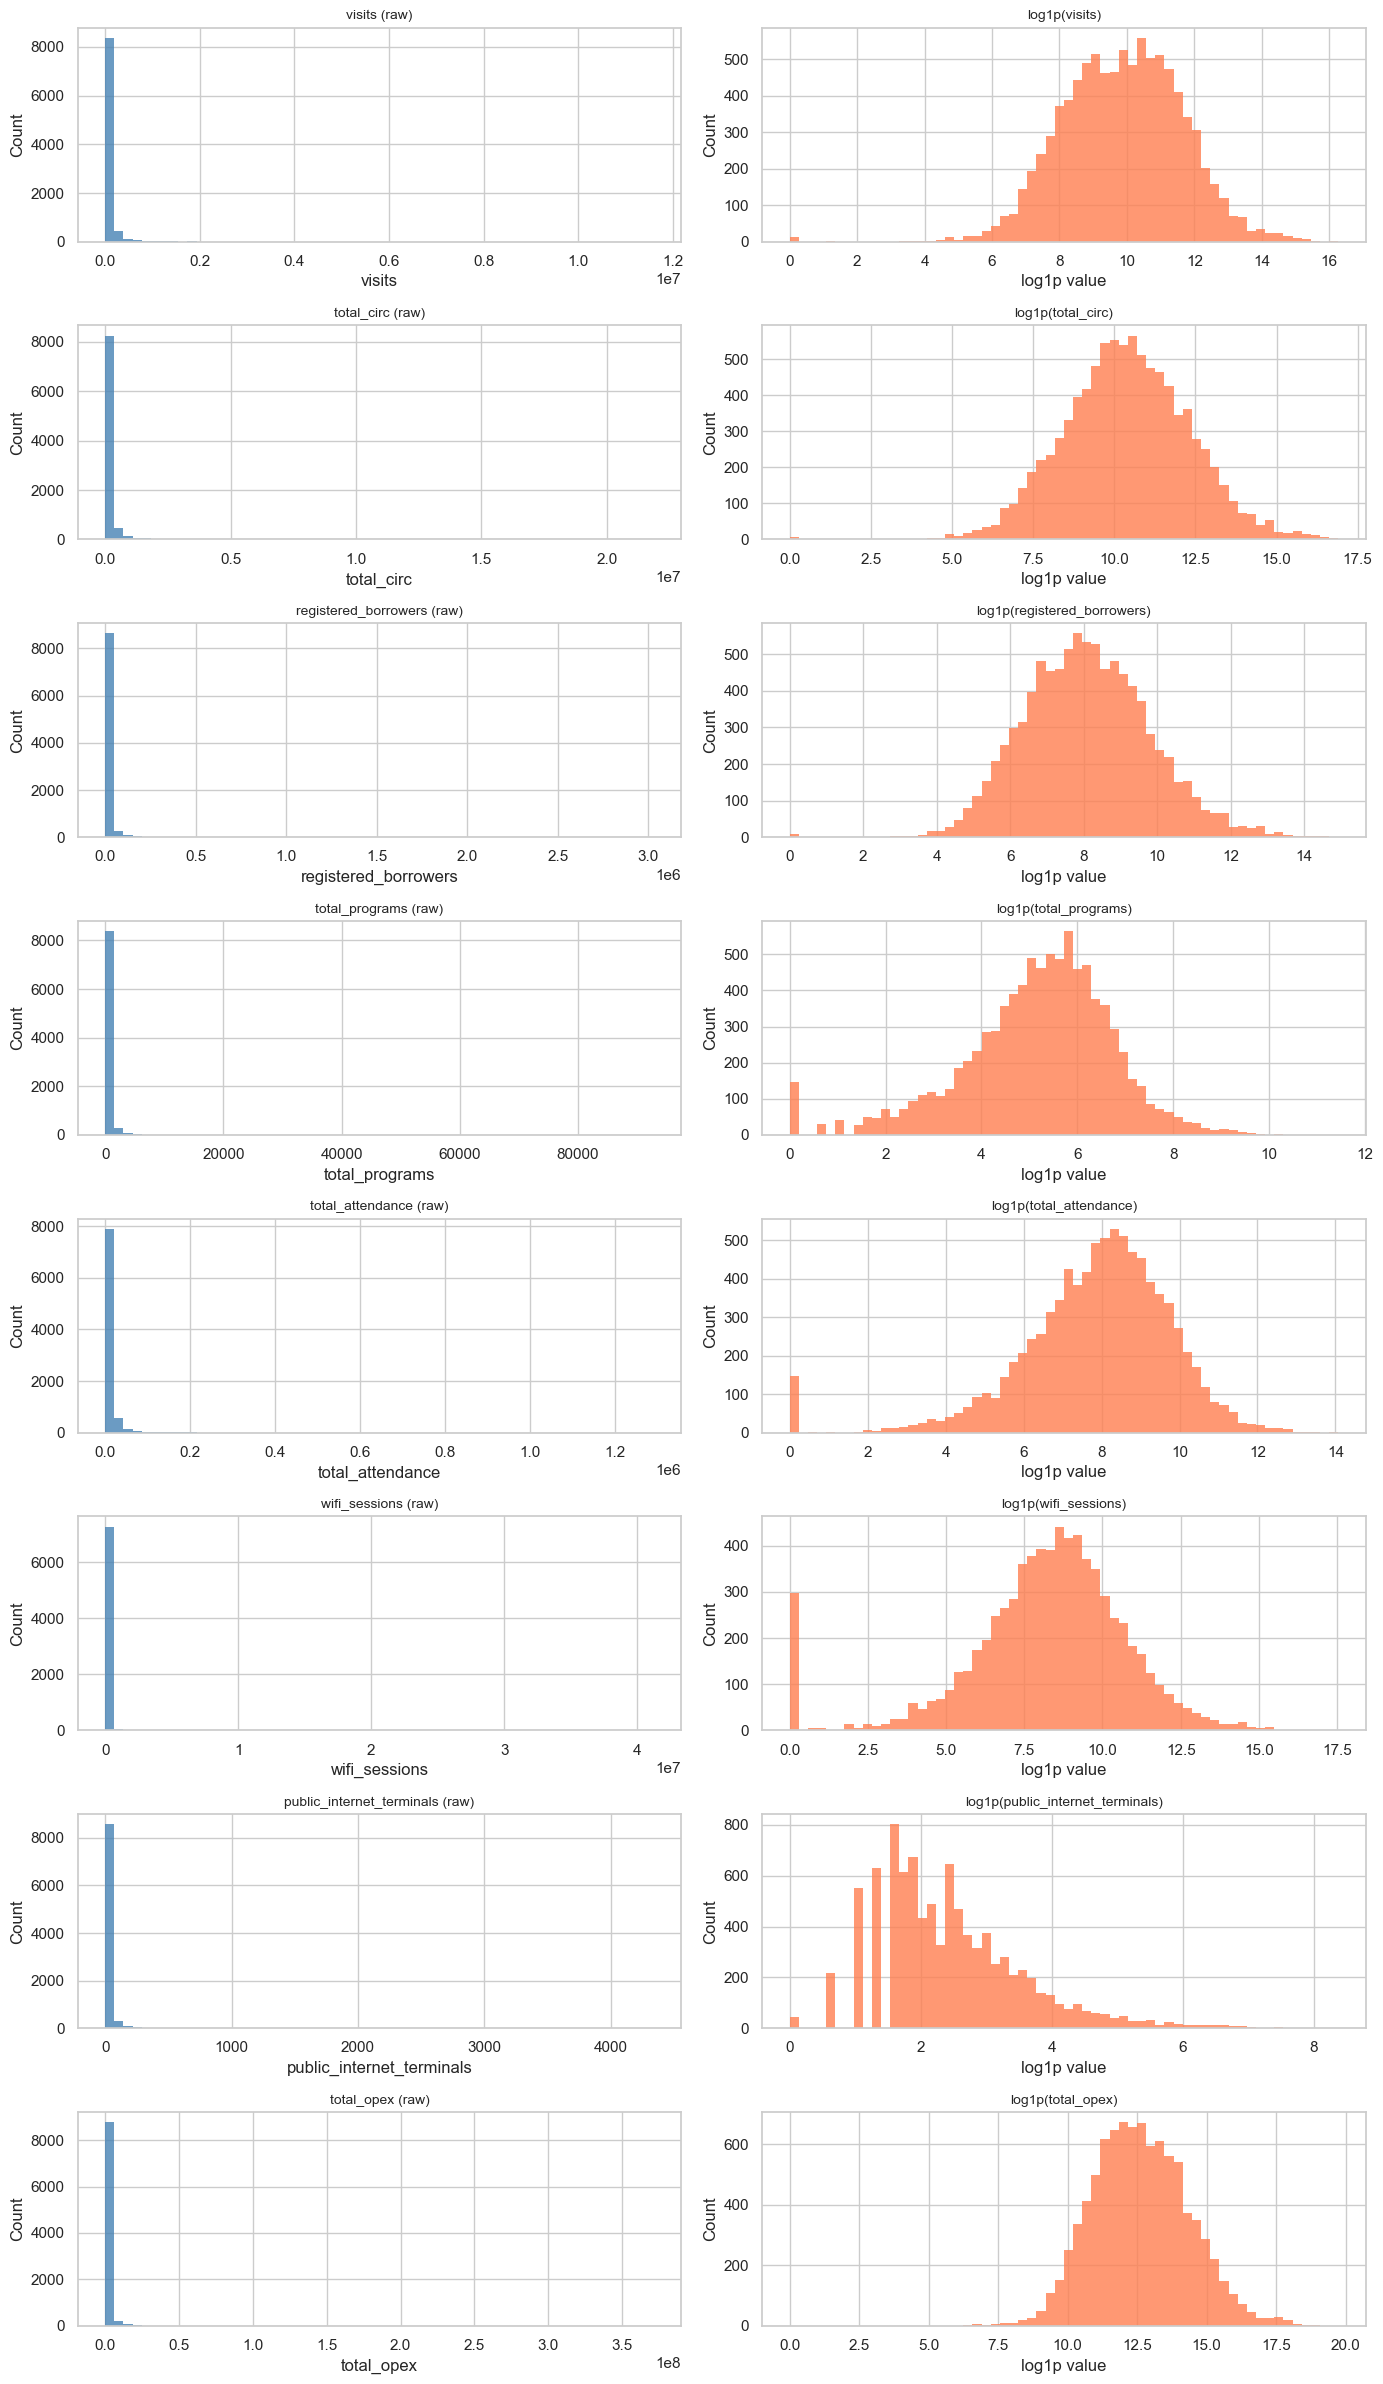

Saved: fig_distributions.png


In [410]:
# ── Distribution plots for key usage variables (raw vs log) ──
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

plot_vars = ["visits", "total_circ", "registered_borrowers",
             "total_programs", "total_attendance", "wifi_sessions",
             "public_internet_terminals", "total_opex"]

for i, col in enumerate(plot_vars):
    ax_raw = axes[i * 2 // 4 * 2 + i % 4]   # simplified: just use flat index
    pass  # replaced below with cleaner loop

fig.clear()
fig, axes = plt.subplots(len(plot_vars), 2, figsize=(14, len(plot_vars) * 3))

for i, col in enumerate(plot_vars):
    series = df[col].dropna()
    # Raw
    axes[i, 0].hist(series, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i, 0].set_title(f"{col} (raw)", fontsize=10)
    axes[i, 0].set_xlabel(col); axes[i, 0].set_ylabel("Count")
    # Log-transformed
    log_series = np.log1p(series)
    axes[i, 1].hist(log_series, bins=60, color="coral", edgecolor="none", alpha=0.8)
    axes[i, 1].set_title(f"log1p({col})", fontsize=10)
    axes[i, 1].set_xlabel("log1p value"); axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: fig_distributions.png")


In [411]:
# ── Outlier detection via IQR ─────────────────────────────────
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    return mask.mean() * 100

outlier_pct = df[USAGE_COLS].apply(lambda c: iqr_outlier_pct(c.dropna()))
outlier_pct = outlier_pct.rename("outlier_pct_iqr").sort_values(ascending=False)
print("Outlier % by column (IQR ×1.5 rule):")
print(outlier_pct.to_string())


Outlier % by column (IQR ×1.5 rule):
wifi_sessions               13.81
total_circ                  12.94
hrs_open                    12.42
total_opex                  12.41
registered_borrowers        12.17
pop_lsa                     11.92
total_staff_fte             11.50
public_internet_terminals   11.33
visits                      10.90
total_attendance            10.56
total_programs               8.75


### 2.3 Geographic overview — state-level medians

In [412]:
# ── State-level aggregation ───────────────────────────────────
state_summary = df.groupby("state").agg(
    n_libraries         = ("fscskey", "count"),
    median_visits       = ("visits", "median"),
    median_circ         = ("total_circ", "median"),
    median_income_served= ("median_hh_income", "median"),
    median_poverty_pct  = ("poverty_rate_all_pct", "median"),
).reset_index().sort_values("median_visits", ascending=False)

print("Top 10 states by median library visits:")
state_summary.head(10).to_string(index=False)


Top 10 states by median library visits:


'state  n_libraries  median_visits  median_circ  median_income_served  median_poverty_pct\n   DC            1   3,027,858.00 7,041,325.00            106,287.00                3.40\n   HI            1   1,330,468.00 4,980,574.00            104,264.00                3.40\n   MD           25     289,327.00   707,579.00             91,146.00                5.30\n   FL           79     200,616.00   338,621.00             73,099.00               12.30\n   CA          186     180,891.50   322,428.50             89,672.00                6.80\n   GA           60     139,516.50   214,501.50             57,820.50               13.30\n   NC           84     122,461.00   226,447.00             62,028.50               10.40\n   MP            1     121,269.00    30,402.00                   NaN                 NaN\n   VA           94      95,189.50   145,162.50             66,717.00                6.60\n   SC           42      84,710.50   137,785.00             56,320.00               10.15'

### 2.4 Correlation matrix — socioeconomic predictors × library usage

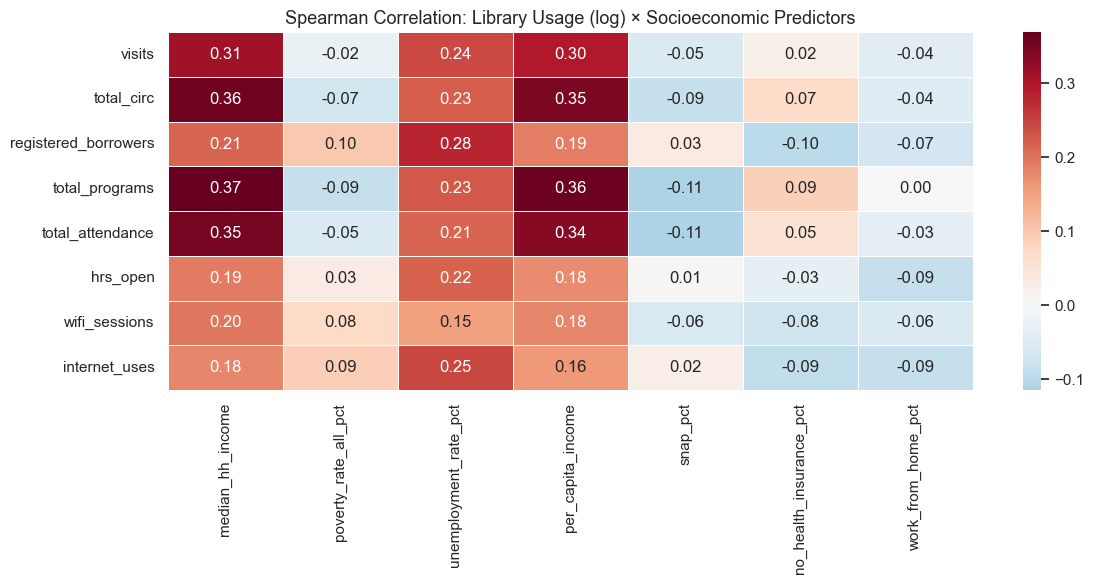

Saved: fig_correlation_heatmap.png


In [413]:
# ── Select columns with enough valid data ────────────────────
CORR_USAGE = ["visits", "total_circ", "registered_borrowers",
              "total_programs", "total_attendance",
              "hrs_open", "wifi_sessions", "internet_uses"]

CORR_SOC   = ["median_hh_income", "poverty_rate_all_pct",
              "unemployment_rate_pct", "per_capita_income",
              "snap_pct", "no_health_insurance_pct",
              "work_from_home_pct"]

corr_df = df[CORR_USAGE + CORR_SOC].copy()

# Log-transform usage (right-skewed)
for col in CORR_USAGE:
    corr_df[f"log_{col}"] = np.log1p(corr_df[col])

log_usage = [f"log_{c}" for c in CORR_USAGE]
corr_matrix = corr_df[log_usage + CORR_SOC].corr(method="spearman")

# ── Plot: only the usage × socioeconomic block ───────────────
cross_corr = corr_matrix.loc[log_usage, CORR_SOC]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax,
            yticklabels=[c.replace("log_", "") for c in log_usage])
ax.set_title("Spearman Correlation: Library Usage (log) × Socioeconomic Predictors", fontsize=13)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: fig_correlation_heatmap.png")


In [414]:
# ── Highlight strongest correlations ─────────────────────────
cross_long = cross_corr.stack().reset_index()
cross_long.columns = ["usage_metric", "socio_predictor", "spearman_r"]
cross_long["abs_r"] = cross_long["spearman_r"].abs()
print("Top 15 correlations (by |r|):")
print(cross_long.sort_values("abs_r", ascending=False).head(15).to_string(index=False))


Top 15 correlations (by |r|):
            usage_metric       socio_predictor  spearman_r  abs_r
      log_total_programs      median_hh_income        0.37   0.37
      log_total_programs     per_capita_income        0.36   0.36
          log_total_circ      median_hh_income        0.36   0.36
    log_total_attendance      median_hh_income        0.35   0.35
          log_total_circ     per_capita_income        0.35   0.35
    log_total_attendance     per_capita_income        0.34   0.34
              log_visits      median_hh_income        0.31   0.31
              log_visits     per_capita_income        0.30   0.30
log_registered_borrowers unemployment_rate_pct        0.28   0.28
       log_internet_uses unemployment_rate_pct        0.25   0.25
              log_visits unemployment_rate_pct        0.24   0.24
      log_total_programs unemployment_rate_pct        0.23   0.23
          log_total_circ unemployment_rate_pct        0.23   0.23
            log_hrs_open unemployment_rate_pct

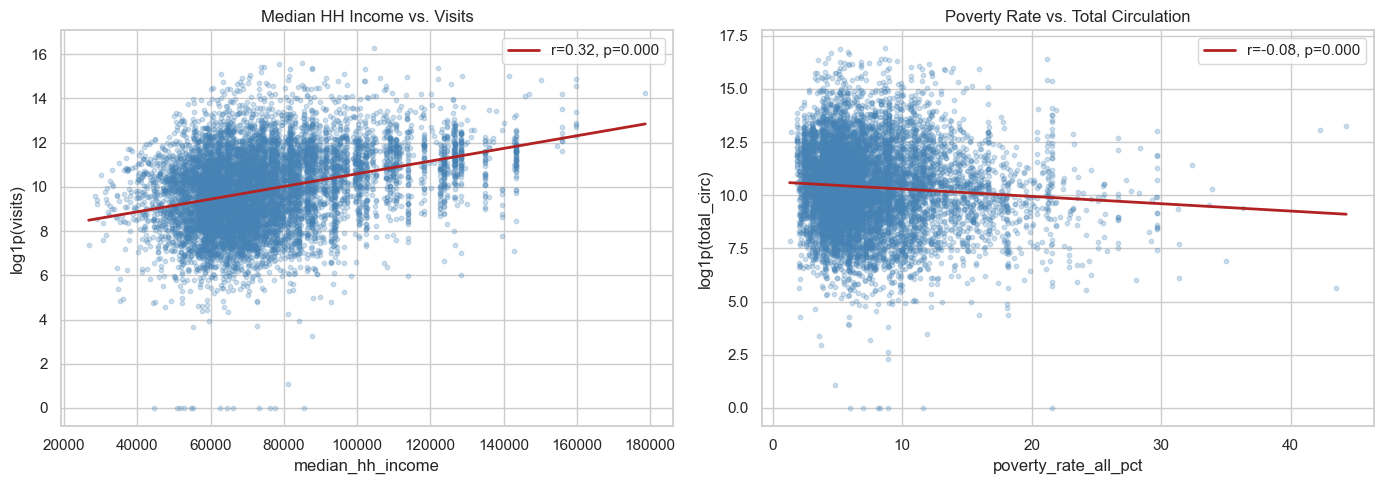

Saved: fig_scatter_preview.png


In [415]:
# ── Scatter: median household income vs. visits/capita (preview) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (x, y, title) in zip(axes, [
    ("median_hh_income", "visits",     "Median HH Income vs. Visits"),
    ("poverty_rate_all_pct", "total_circ", "Poverty Rate vs. Total Circulation"),
]):
    sub = df[[x, y]].dropna()
    ax.scatter(sub[x], np.log1p(sub[y]), alpha=0.25, s=10, color="steelblue")
    # Trend line
    m, b, r, p, _ = stats.linregress(sub[x], np.log1p(sub[y]))
    xr = np.linspace(sub[x].min(), sub[x].max(), 200)
    ax.plot(xr, m * xr + b, color="firebrick", lw=2, label=f"r={r:.2f}, p={p:.3f}")
    ax.set_xlabel(x); ax.set_ylabel(f"log1p({y})")
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("fig_scatter_preview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: fig_scatter_preview.png")


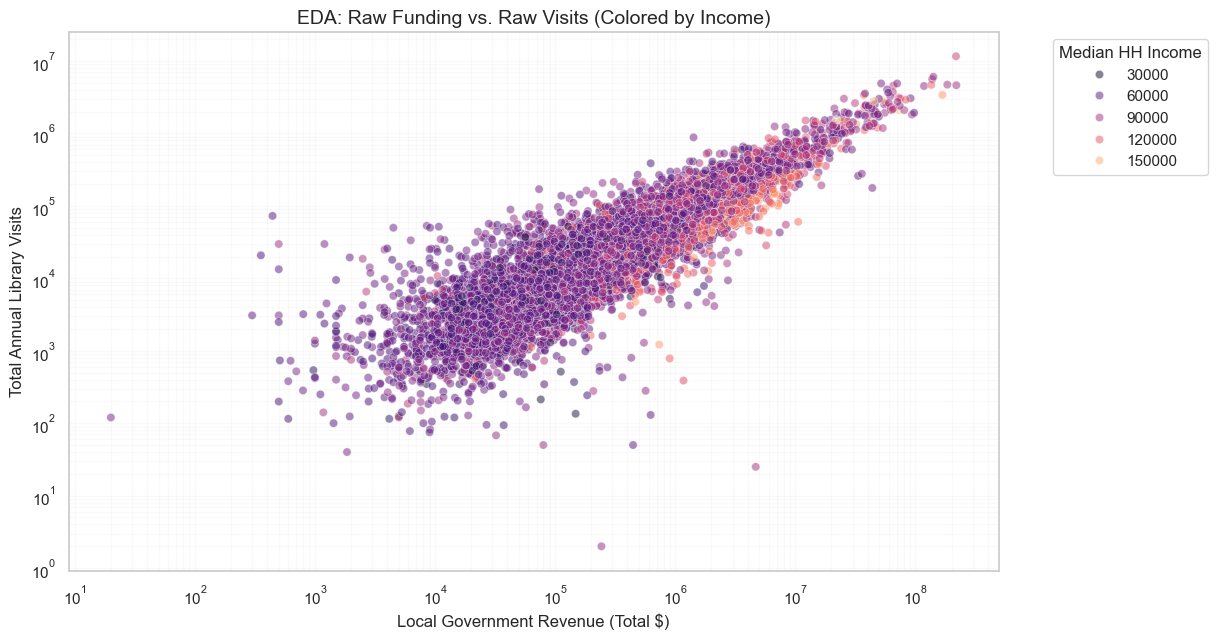

Saved: Does Funding Drive Usage.png


In [416]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=merged, 
    x='local_govt_revenue', 
    y='visits', 
    hue='median_hh_income', 
    palette='magma', 
    alpha=0.5
)

# We still use log scales because library sizes vary so much (e.g., NYC vs. a small town)
plt.xscale('log')
plt.yscale('log')

plt.title('EDA: Raw Funding vs. Raw Visits (Colored by Income)', fontsize=14)
plt.xlabel('Local Government Revenue (Total $)', fontsize=12)
plt.ylabel('Total Annual Library Visits', fontsize=12)
plt.legend(title='Median HH Income', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, which="both", ls="-", alpha=0.1)
plt.savefig("Does Funding Drive Usage.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: Does Funding Drive Usage.png")


---
## §3 — Feature Engineering
*Apr 1 – 6*

### 3.1 Per-capita conversion
Dividing raw counts by population of legal service area (POPU_LSA) makes
libraries of different sizes comparable. A small rural library serving 1,000
people looks very different in raw counts vs. a large urban system serving 500,000.


In [417]:
fe = merged[merged["pop_lsa"].notna() & (merged["pop_lsa"] > 0)].copy()

# ── Per-capita usage metrics ──────────────────────────────────
PC_PAIRS = [
    ("visits",               "visits_pc"),
    ("total_circ",           "circ_pc"),
    ("registered_borrowers", "regbor_pc"),
    ("total_programs",       "programs_pc"),
    ("total_attendance",     "attendance_pc"),
    ("hrs_open",             "hrs_open_pc"),
    ("public_internet_terminals", "terminals_pc"),
    ("wifi_sessions",        "wifi_pc"),
    ("total_opex",           "opex_pc"),
    ("total_income",         "income_pc"),
    ("total_staff_fte",      "staff_fte_pc"),
]

for raw_col, pc_col in PC_PAIRS:
    fe[pc_col] = fe[raw_col] / fe["pop_lsa"]

PC_COLS = [pc for _, pc in PC_PAIRS]
print("Per-capita columns created:")
fe[PC_COLS].describe().T.round(4)


Per-capita columns created:


,count,mean,std,min,25%,50%,75%,max
visits_pc,"9,169.00",3.75,4.29,0.00,1.59,2.77,4.52,115.37
circ_pc,"9,170.00",6.27,6.00,0.00,2.58,4.90,8.11,140.12
regbor_pc,"9,170.00",0.58,0.81,0.00,0.29,0.44,0.68,39.33
programs_pc,"8,860.00",0.05,0.12,0.00,0.01,0.02,0.05,7.86
attendance_pc,"8,836.00",0.66,1.35,0.00,0.18,0.38,0.75,63.16
hrs_open_pc,"9,040.00",0.63,1.50,0.00,0.14,0.31,0.72,104.29
terminals_pc,"9,170.00",0.00,0.00,0.00,0.00,0.00,0.00,0.14
wifi_pc,"7,371.00",2.24,21.33,0.00,0.18,0.55,1.53,"1,698.34"
opex_pc,"9,170.00",55.26,75.56,0.00,25.91,42.23,65.40,"4,211.68"
income_pc,"9,170.00",61.39,100.28,0.00,27.74,45.92,71.58,"4,892.56"


### 3.2 Log-transform skewed variables

In [418]:
# ── log1p transform on per-capita and raw count columns ──────
LOG_TARGETS = PC_COLS + ["visits", "total_circ", "total_opex",
                          "median_hh_income", "per_capita_income"]

for col in LOG_TARGETS:
    if col in fe.columns:
        fe[f"log_{col}"] = np.log1p(fe[col].clip(lower=0))

print("Log-transformed columns added:", sum(1 for c in fe.columns if c.startswith("log_")))


Log-transformed columns added: 16


### 3.3 Derived ratio / composite features

In [419]:
# ── Financial efficiency ratios ──────────────────────────────
fe["cost_per_visit"]    = fe["total_opex"] / fe["visits"].replace(0, np.nan)
fe["cost_per_circ"]     = fe["total_opex"] / fe["total_circ"].replace(0, np.nan)
fe["circ_per_visit"]    = fe["total_circ"] / fe["visits"].replace(0, np.nan)
fe["digital_share_circ"]= fe["elec_mat_circ"] / fe["total_circ"].replace(0, np.nan)

# ── Staffing ratio ────────────────────────────────────────────
fe["staff_per_1k_pop"]  = fe["total_staff_fte"] / fe["pop_lsa"] * 1000

# ── Program intensity ─────────────────────────────────────────
fe["attendance_per_program"] = fe["total_attendance"] / fe["total_programs"].replace(0, np.nan)

# ── Digital engagement index (simple sum of z-scores) ─────────
digital_vars = ["internet_uses", "wifi_sessions", "elec_mat_circ", "elec_content_uses"]
for v in digital_vars:
    if v in fe.columns:
        fe[f"z_{v}"] = (fe[v] - fe[v].mean()) / fe[v].std()

z_cols = [f"z_{v}" for v in digital_vars if v in fe.columns]
if z_cols:
    fe["digital_engagement_idx"] = fe[z_cols].mean(axis=1)

print("Derived feature columns:")
derived = ["cost_per_visit", "cost_per_circ", "circ_per_visit",
           "digital_share_circ", "staff_per_1k_pop",
           "attendance_per_program", "digital_engagement_idx"]
fe[derived].describe().T.round(3)


Derived feature columns:


,count,mean,std,min,25%,50%,75%,max
cost_per_visit,"9,156.00",54.68,"2,186.07",0.00,10.50,15.13,22.36,"155,215.48"
cost_per_circ,"9,163.00",23.58,691.76,0.00,5.96,8.89,13.59,"65,588.00"
circ_per_visit,"9,156.00",2.90,52.77,0.00,1.15,1.70,2.44,"4,580.00"
digital_share_circ,"9,163.00",0.20,0.14,0.00,0.12,0.18,0.26,1.00
staff_per_1k_pop,"9,170.00",0.76,1.05,0.00,0.36,0.57,0.88,53.53
attendance_per_program,"8,680.00",19.32,19.07,0.00,10.72,16.25,23.50,"1,123.18"
digital_engagement_idx,"9,170.00",-0.00,0.70,-0.16,-0.14,-0.12,-0.07,21.68


### 3.4 Winsorize to reduce outlier influence

In [420]:
from scipy.stats import mstats

def winsorize_col(series, limits=(0.01, 0.01)):
    """Winsorize at 1st and 99th percentile."""
    clean = series.dropna()
    if len(clean) == 0:
        return series
    arr = mstats.winsorize(clean, limits=limits)
    result = series.copy()
    result[series.notna()] = arr
    return result

WIN_COLS = PC_COLS + derived
for col in WIN_COLS:
    if col in fe.columns:
        fe[f"w_{col}"] = winsorize_col(fe[col])

print(f"Winsorized columns created: {sum(1 for c in fe.columns if c.startswith('w_'))}")


Winsorized columns created: 18


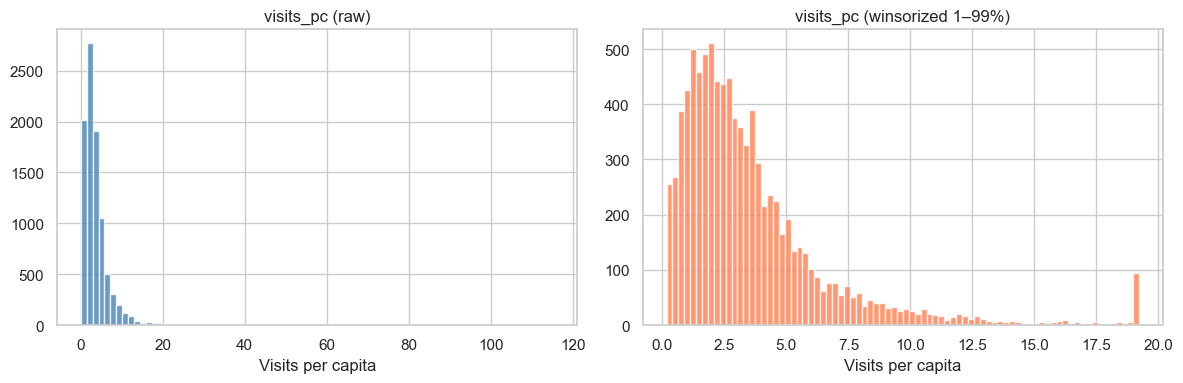

In [421]:
# ── Distribution comparison: raw vs winsorized visits/capita ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fe["visits_pc"].dropna().hist(bins=80, ax=axes[0], color="steelblue", alpha=0.8)
axes[0].set_title("visits_pc (raw)"); axes[0].set_xlabel("Visits per capita")
fe["w_visits_pc"].dropna().hist(bins=80, ax=axes[1], color="coral", alpha=0.8)
axes[1].set_title("visits_pc (winsorized 1–99%)"); axes[1].set_xlabel("Visits per capita")
plt.tight_layout()
plt.savefig("fig_winsorize_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


In [422]:
# ── Save feature-engineered dataset ──────────────────────────
fe.to_csv("features_pls_acs.csv", index=False)
print(f"Saved features_pls_acs.csv: {fe.shape[0]:,} rows × {fe.shape[1]} columns")


Saved features_pls_acs.csv: 9,210 rows × 114 columns


---
## §4 — Data Quality & Reproducibility Documentation
*Apr 7 – 12*

This section produces structured documentation of the data pipeline for inclusion
in the final project report.

### 4.1 Data provenance metadata


In [423]:
import datetime, hashlib, os

provenance = {
    "generated_at": datetime.datetime.now().isoformat(),
    "files": {
        "PLS_FY23_AE_pud23i.csv": {
            "source": "IMLS Public Library Survey FY2023 Agency-level microdata",
            "url": "https://www.imls.gov/research-evaluation/data-collection/public-libraries-survey",
            "year": 2023,
            "unit_of_obs": "library_agency",
            "n_rows": len(pls_raw),
            "n_cols": pls_raw.shape[1],
        },
        "pls_fy23_outlet_pud23i.csv": {
            "source": "IMLS Public Library Survey FY2023 Outlet-level microdata",
            "url": "https://www.imls.gov/research-evaluation/data-collection/public-libraries-survey",
            "year": 2023,
            "unit_of_obs": "library_outlet",
            "n_rows": len(outlet_raw),
            "n_cols": outlet_raw.shape[1],
        },
        "ACSDP5Y2023_DP03-Data.csv": {
            "source": "U.S. Census Bureau ACS 5-Year Estimates 2023, Table DP03",
            "url": "https://data.census.gov",
            "survey_years": "2019–2023",
            "unit_of_obs": "county (FIPS)",
            "n_rows": len(acs_raw),
            "n_cols": acs_raw.shape[1],
        },
    }
}

import json
print(json.dumps(provenance, indent=2))


{
  "generated_at": "2026-05-06T00:32:31.642531",
  "files": {
    "PLS_FY23_AE_pud23i.csv": {
      "source": "IMLS Public Library Survey FY2023 Agency-level microdata",
      "url": "https://www.imls.gov/research-evaluation/data-collection/public-libraries-survey",
      "year": 2023,
      "unit_of_obs": "library_agency",
      "n_rows": 9252,
      "n_cols": 187
    },
    "pls_fy23_outlet_pud23i.csv": {
      "source": "IMLS Public Library Survey FY2023 Outlet-level microdata",
      "url": "https://www.imls.gov/research-evaluation/data-collection/public-libraries-survey",
      "year": 2023,
      "unit_of_obs": "library_outlet",
      "n_rows": 17586,
      "n_cols": 37
    },
    "ACSDP5Y2023_DP03-Data.csv": {
      "source": "U.S. Census Bureau ACS 5-Year Estimates 2023, Table DP03",
      "url": "https://data.census.gov",
      "survey_years": "2019\u20132023",
      "unit_of_obs": "county (FIPS)",
      "n_rows": 3222,
      "n_cols": 551
    }
  }
}


### 4.2 Column-level data dictionary

In [424]:
# ── Build a data dictionary for the merged/feature dataset ───
def col_profile(series, label=""):
    return {
        "label":      label,
        "dtype":      str(series.dtype),
        "n_valid":    int(series.notna().sum()),
        "pct_missing":round(series.isna().mean() * 100, 1),
        "min":        round(float(series.min()), 4) if series.notna().any() else None,
        "max":        round(float(series.max()), 4) if series.notna().any() else None,
        "mean":       round(float(series.mean()), 4) if pd.api.types.is_numeric_dtype(series) else None,
        "median":     round(float(series.median()), 4) if pd.api.types.is_numeric_dtype(series) else None,
    }

DICT_COLS = {
    # PLS usage
    "visits":                "Total annual visits to all outlets",
    "total_circ":            "Total annual circulation (physical + digital)",
    "kids_circ":             "Children's circulation",
    "elec_mat_circ":         "Electronic materials circulation",
    "registered_borrowers":  "Registered borrowers (active cardholders)",
    "total_programs":        "Total programs offered (all age groups)",
    "total_attendance":      "Total attendance at library programs",
    "hrs_open":              "Total annual public service hours",
    "public_internet_terminals": "Number of public internet access terminals",
    "wifi_sessions":         "Public Wi-Fi sessions",
    "total_staff_fte":       "Total paid staff (FTE)",
    "total_opex":            "Total operating expenditures ($)",
    "total_income":          "Total revenue from all sources ($)",
    "pop_lsa":               "Population of legal service area",
    # ACS socioeconomic
    "median_hh_income":      "Median household income, ACS 5yr 2023 ($)",
    "poverty_rate_all_pct":  "% of all people below poverty line",
    "unemployment_rate_pct": "Civilian labor force unemployment rate (%)",
    "per_capita_income":     "Per capita income ($)",
    "snap_pct":              "% of households receiving SNAP benefits",
    "no_health_insurance_pct":"% of population without health insurance",
    "work_from_home_pct":    "% of workers who work from home",
    # Engineered
    "visits_pc":             "Annual visits per capita (pop_lsa denominator)",
    "circ_pc":               "Annual circulation per capita",
    "opex_pc":               "Operating expenditures per capita ($)",
    "cost_per_visit":        "Operating expenditure per visit ($)",
    "digital_share_circ":    "Proportion of circulation that is electronic",
    "staff_per_1k_pop":      "FTE staff per 1,000 population served",
    "digital_engagement_idx":"Composite z-score index of digital service metrics",
}

dict_rows = []
for col, label in DICT_COLS.items():
    if col in fe.columns:
        profile = col_profile(fe[col], label)
        profile["column"] = col
        dict_rows.append(profile)

data_dict = pd.DataFrame(dict_rows).set_index("column")
data_dict


,label,dtype,n_valid,pct_missing,min,max,mean,median
column,,,,,,,,
visits,Total annual visits to all outlets,float64,9169,0.40,0.00,"11,597,585.00","87,590.77","20,251.00"
total_circ,Total annual circulation (physical + digital),float64,9170,0.40,0.00,"21,873,148.00","214,073.46","31,933.00"
kids_circ,Children's circulation,float64,9170,0.40,0.00,"7,935,151.00","78,518.17","10,568.00"
elec_mat_circ,Electronic materials circulation,float64,9170,0.40,0.00,"14,622,381.00","59,452.64","5,638.00"
registered_borrowers,Registered borrowers (active cardholders),float64,9170,0.40,0.00,"3,029,366.00","16,980.85","3,084.00"
total_programs,Total programs offered (all age groups),float64,8860,3.80,0.00,"92,825.00",514.83,210.00
total_attendance,Total attendance at library programs,float64,8836,4.10,0.00,"1,290,578.00","10,582.81","3,239.50"
hrs_open,Total annual public service hours,float64,9040,1.80,0.00,"216,654.00","3,964.65","2,296.00"
public_internet_terminals,Number of public internet access terminals,float64,9170,0.40,0.00,"4,341.00",29.24,9.00


In [425]:
# ── Export data dictionary ────────────────────────────────────
data_dict.to_csv("data_dictionary.csv")
print("Saved: data_dictionary.csv")


Saved: data_dictionary.csv


### 4.3 Known limitations & methodological notes

In [426]:
limitations = """
DATA QUALITY & METHODOLOGICAL NOTES
====================================

1. FIPS MERGE COVERAGE
   ~{pct_matched:.0f}% of PLS library agencies were matched to an ACS county record.
   Libraries that serve multiple counties (LSABOUND='Y') are assigned to a single
   county using their census tract centroid — a deliberate simplification.
   Libraries in unincorporated places or with missing CENTRACT data may be unmatched.

2. PLS SENTINEL VALUES
   The PLS encodes special non-response codes: -1 (not applicable), -3 (confidential),
   -9 (missing). All three are replaced with NaN before analysis. Flag columns
   (F_VISITS, F_TOTCIR, etc.) encode additional quality codes ('R' = revised,
   'H' = imputed, 'CT' = closed-then-reopened). These flags are retained in
   pls_cleaned.csv for reference but not yet used to filter the analysis.

3. ACS SURVEY UNCERTAINTY
   ACS 5-year estimates have margins of error, especially for small counties.
   Margin-of-error columns (suffix 'M') were dropped in §1 to keep the dataset
   manageable. For robust inference on small counties, restore and use them.

4. UNIT OF ANALYSIS
   The merged dataset is at the *library agency* level, not at the outlet (branch)
   level. Agencies vary enormously in size. Per-capita metrics (§3) partially address
   this but do not fully control for urban/rural differences in service area definition.

5. TIME ALIGNMENT
   PLS FY2023 covers fiscal year 2022–23 (varies by library).
   ACS 5-year 2023 estimates are averaged over 2019–2023.
   This temporal mismatch is standard practice in cross-sectional library research
   but means ACS figures reflect pre-pandemic norms mixed with pandemic-era data.

6. WINSORIZATION THRESHOLD
   Per-capita metrics are winsorized at the 1st and 99th percentiles. This is a
   conservative threshold; consider 5th/95th for smaller analytical subsets.
""".format(pct_matched=fe["median_hh_income"].notna().mean() * 100)

print(limitations)
with open("limitations_notes.txt", "w") as f:
    f.write(limitations)
print("Saved: limitations_notes.txt")



DATA QUALITY & METHODOLOGICAL NOTES

1. FIPS MERGE COVERAGE
   ~100% of PLS library agencies were matched to an ACS county record.
   Libraries that serve multiple counties (LSABOUND='Y') are assigned to a single
   county using their census tract centroid — a deliberate simplification.
   Libraries in unincorporated places or with missing CENTRACT data may be unmatched.

2. PLS SENTINEL VALUES
   The PLS encodes special non-response codes: -1 (not applicable), -3 (confidential),
   -9 (missing). All three are replaced with NaN before analysis. Flag columns
   (F_VISITS, F_TOTCIR, etc.) encode additional quality codes ('R' = revised,
   'H' = imputed, 'CT' = closed-then-reopened). These flags are retained in
   pls_cleaned.csv for reference but not yet used to filter the analysis.

3. ACS SURVEY UNCERTAINTY
   ACS 5-year estimates have margins of error, especially for small counties.
   Margin-of-error columns (suffix 'M') were dropped in §1 to keep the dataset
   manageable. For robu

### 4.4 Reproducibility checklist

In [427]:
import sys

print("=== REPRODUCIBILITY CHECKLIST ===")
print(f"Python version  : {sys.version.split()[0]}")
print(f"pandas          : {pd.__version__}")
print(f"numpy           : {np.__version__}")
print(f"matplotlib      : {plt.matplotlib.__version__}")
print(f"seaborn         : {sns.__version__}")
print()
print("=== OUTPUT FILES PRODUCED ===")
outputs = [
    "pls_cleaned.csv",
    "acs_cleaned.csv",
    "merged_pls_acs.csv",
    "features_pls_acs.csv",
    "data_dictionary.csv",
    "limitations_notes.txt",
    "fig_distributions.png",
    "fig_correlation_heatmap.png",
    "fig_scatter_preview.png",
    "fig_winsorize_comparison.png",
]
for f in outputs:
    exists = os.path.exists(f)
    print(f"  {'✓' if exists else '✗'}  {f}")

print()
print("To reproduce from scratch:")
print("  1. Place all four source CSVs in the same directory as this notebook.")
print("  2. Run all cells top-to-bottom (Kernel → Restart & Run All).")
print("  3. All outputs will be written to the working directory.")


=== REPRODUCIBILITY CHECKLIST ===
Python version  : 3.12.3
pandas          : 2.2.2
numpy           : 1.26.4
matplotlib      : 3.8.4
seaborn         : 0.13.2

=== OUTPUT FILES PRODUCED ===
  ✓  pls_cleaned.csv
  ✓  acs_cleaned.csv
  ✓  merged_pls_acs.csv
  ✓  features_pls_acs.csv
  ✓  data_dictionary.csv
  ✓  limitations_notes.txt
  ✓  fig_distributions.png
  ✓  fig_correlation_heatmap.png
  ✓  fig_scatter_preview.png
  ✓  fig_winsorize_comparison.png

To reproduce from scratch:
  1. Place all four source CSVs in the same directory as this notebook.
  2. Run all cells top-to-bottom (Kernel → Restart & Run All).
  3. All outputs will be written to the working directory.


### 4.5 File organization map

In [428]:
org_map = """
project/
├── data/
│   ├── raw/                          ← original source files (do not edit)
│   │   ├── PLS_FY23_AE_pud23i.csv
│   │   ├── pls_fy23_outlet_pud23i.csv
│   │   ├── ACSDP5Y2023_DP03-Data.csv
│   │   └── ACSDP5Y2023_DP03-Column-Metadata.csv
│   └── processed/                    ← outputs of this notebook
│       ├── pls_cleaned.csv
│       ├── acs_cleaned.csv
│       ├── merged_pls_acs.csv        ← §1 merge output
│       └── features_pls_acs.csv     ← §3 feature-engineered dataset
├── docs/
│   ├── data_dictionary.csv           ← §4 column-level documentation
│   └── limitations_notes.txt         ← §4 methodological caveats
├── figures/
│   ├── fig_distributions.png
│   ├── fig_correlation_heatmap.png
│   ├── fig_scatter_preview.png
│   └── fig_winsorize_comparison.png
└── notebooks/
    └── 01_cleaning_eda_features.ipynb  ← this notebook
"""
print(org_map)



project/
├── data/
│   ├── raw/                          ← original source files (do not edit)
│   │   ├── PLS_FY23_AE_pud23i.csv
│   │   ├── pls_fy23_outlet_pud23i.csv
│   │   ├── ACSDP5Y2023_DP03-Data.csv
│   │   └── ACSDP5Y2023_DP03-Column-Metadata.csv
│   └── processed/                    ← outputs of this notebook
│       ├── pls_cleaned.csv
│       ├── acs_cleaned.csv
│       ├── merged_pls_acs.csv        ← §1 merge output
│       └── features_pls_acs.csv     ← §3 feature-engineered dataset
├── docs/
│   ├── data_dictionary.csv           ← §4 column-level documentation
│   └── limitations_notes.txt         ← §4 methodological caveats
├── figures/
│   ├── fig_distributions.png
│   ├── fig_correlation_heatmap.png
│   ├── fig_scatter_preview.png
│   └── fig_winsorize_comparison.png
└── notebooks/
    └── 01_cleaning_eda_features.ipynb  ← this notebook



## §5 — Data Modeling & Reproducibility
*April 13–17*


### 5.1  Prepare the modeling dataset

In [429]:
from scipy.stats.mstats import winsorize
PREDICTORS = {
    "poverty_rate_all_pct":    "Poverty Rate (%)",
    "unemployment_rate_pct":   "Unemployment Rate (%)",
    "median_hh_income":        "Median HH Income ($)",
    "snap_pct":                "SNAP Recipients (%)",
    "no_health_insurance_pct": "No Health Insurance (%)",
    "work_from_home_pct":      "Work From Home (%)",
    "opex_pc":                 "Operating Expenditure / Capita ($)",
    "staff_per_1k_pop":        "Staff per 1,000 Population",
    "hrs_open":                "Annual Hours Open",
}
TARGET = "log_visits_pc"
if TARGET not in fe:
    base = "w_visits_pc" if "w_visits_pc" in fe else "visits_pc"
    fe[TARGET] = np.log1p(fe[base].clip(lower=0))

fe["locale"] = pd.cut(
    fe["pop_lsa"],
    bins=[0, 25_000, 250_000, float("inf")],
    labels=["Rural", "Suburban", "Urban"]
)

cols = [TARGET] + list(PREDICTORS)
mdf = fe[cols].dropna().copy()

# Winsorize first
for col in ["opex_pc", "staff_per_1k_pop", "hrs_open"]:
    if col in mdf:
        mdf[col] = winsorize(mdf[col], limits=(0.01, 0.01))

# Then z-score
mdf = (mdf - mdf.mean()) / mdf.std()

# Add locale after standardization
mdf["locale"] = fe["locale"]

### 5.2  OLS Regression ; Full national model

In [430]:
X = sm.add_constant(mdf[list(PREDICTORS)])
y = mdf[TARGET]

# fit model
model = sm.OLS(y, X).fit(cov_type="HC3")

print(model.summary2())

# extract results to df
coef_df = pd.DataFrame({
    "coef":  model.params[1:],
    "ci_lo": model.conf_int()[0][1:],
    "ci_hi": model.conf_int()[1][1:],
    "pval":  model.pvalues[1:]
})

#Mapping and visualization prep
coef_df.index = [PREDICTORS[c] for c in coef_df.index]

coef_df["sig"] = coef_df["pval"].apply(
    lambda p: "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else ""))
)

# sort the values for plotting
coef_df = coef_df.sort_values("coef")

                    Results: Ordinary least squares
Model:                 OLS               Adj. R-squared:      0.441     
Dependent Variable:    log_visits_pc     AIC:                 20389.9975
Date:                  2026-05-06 00:32  BIC:                 20453.9762
No. Observations:      9034              Log-Likelihood:      -10186.   
Df Model:              8                 F-statistic:         464.8     
Df Residuals:          9025              Prob (F-statistic):  0.00      
R-squared:             0.442             Scale:               0.55887   
------------------------------------------------------------------------
                         Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
------------------------------------------------------------------------
const                    0.0000   0.0079   0.0000 1.0000 -0.0154  0.0154
poverty_rate_all_pct    -0.0242   0.0044  -5.4743 0.0000 -0.0329 -0.0155
unemployment_rate_pct   -0.0521   0.0111  -4.7114 0.0000 -0.0737 -0.0304

### 5.3  Coefficient plot — feature importance

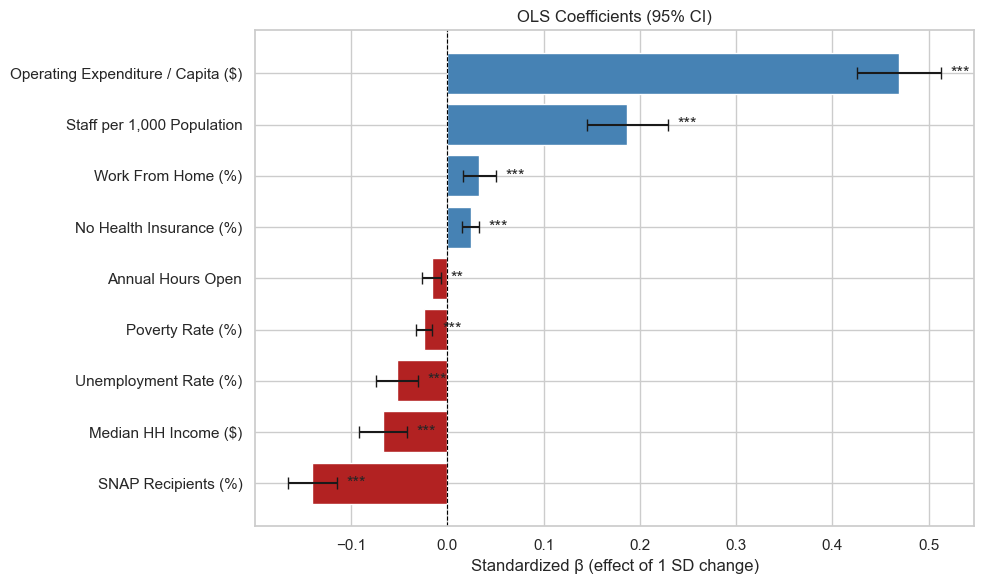

In [431]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    coef_df.index,
    coef_df["coef"],
    color=["steelblue" if c >= 0 else "firebrick" for c in coef_df["coef"]],
    xerr=[coef_df["coef"] - coef_df["ci_lo"],
          coef_df["ci_hi"] - coef_df["coef"]],
    capsize=4
)

# Zero reference line
ax.axvline(0, color="black", linestyle="--", lw=0.8)

# Labels and adding the "*" things
ax.set_xlabel("Standardized β (effect of 1 SD change)")
ax.set_title("OLS Coefficients (95% CI)")

for i, (_, row) in enumerate(coef_df.iterrows()):
    if row["sig"]:
        ax.text(row["ci_hi"] + 0.01, i, row["sig"], va="center")

plt.tight_layout()
plt.savefig("fig_ols_coefficients.png", dpi=130, bbox_inches="tight")
plt.show()

###### Interestingly enough, it seems SNAP Recipients is the most interesting finding since it's negative, meaning counties with more SNAP recipients actually have fewer library visits per capita

### 5.4: Exploring poverty, unemployment, income based on locality

In [436]:
CORE_LABELS = {
    "poverty_rate_all_pct":  "Poverty Rate",
    "unemployment_rate_pct": "Unemployment Rate",
    "median_hh_income":      "Median HH Income",
}

results = []
for loc in ["Rural", "Suburban", "Urban"]:
    sub = mdf[mdf["locale"] == loc][CORE_PREDS + [TARGET]].dropna()
    model = sm.OLS(sub[TARGET], sm.add_constant(sub[CORE_PREDS])).fit(cov_type="HC3")
    for pred in CORE_PREDS:
        results.append({
            "locale":    loc,
            "predictor": CORE_LABELS[pred],
            "coef":      model.params[pred],
            "ci_lo":     model.conf_int().loc[pred, 0],
            "ci_hi":     model.conf_int().loc[pred, 1],
        })

res_df = pd.DataFrame(results)

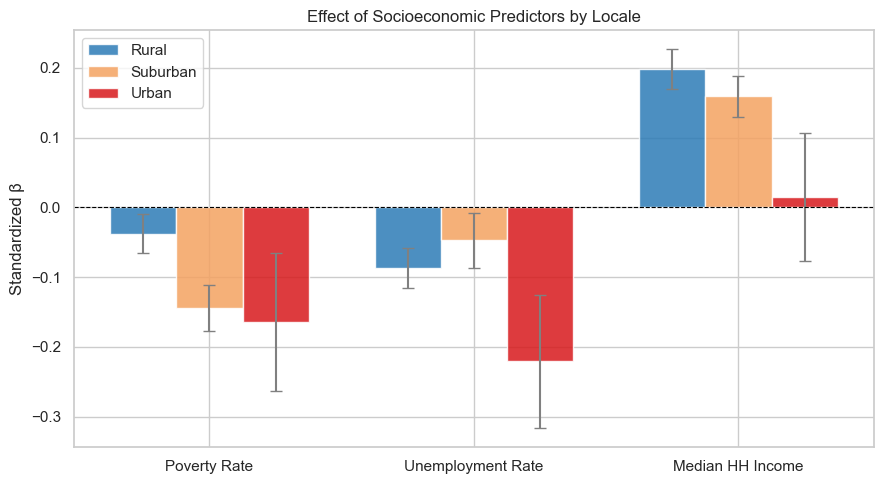

In [438]:
#Plot creation
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"Rural": "#2c7bb6", "Suburban": "#f4a261", "Urban": "#d7191c"}
width, offsets = 0.25, {"Rural": -0.25, "Suburban": 0, "Urban": 0.25}
x = range(len(CORE_LABELS))

for loc in ["Rural", "Suburban", "Urban"]:
    sub = res_df[res_df["locale"] == loc]
    pos = [i + offsets[loc] for i in x]
    ax.bar(pos, sub["coef"], width, label=loc, color=colors[loc], alpha=0.85)
    ax.errorbar(pos, sub["coef"],
                yerr=[sub["coef"] - sub["ci_lo"], sub["ci_hi"] - sub["coef"]],
                fmt="none", ecolor="gray", capsize=4)

ax.set_xticks(list(x))
ax.set_xticklabels(list(CORE_LABELS.values()))
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_ylabel("Standardized β")
ax.set_title("Effect of Socioeconomic Predictors by Locale")
ax.legend()
plt.tight_layout()
plt.savefig("locale_comparison.png", dpi=130, bbox_inches="tight")
plt.show()